# Basic EDA — Dell Data Science Case Study

First pass at getting to know the data before any modeling: what's in the train and inference sets, how each column is typed, and what the main categorical and numeric fields look like.

Starting with pandas since both datasets come as parquet files.

In [2]:
import pandas as pd

## Loading the training data

Reading in `train.parquet` and looking at the first few rows to get a feel for the structure. Each row looks like a work order tied to a sales order, with order info (`order_amt`, `quantity_produced`, `line_qty`), product hierarchy (`lob_desc`, `family_parent_desc`, `family_desc`), and a set of dates for the build process.

In [3]:
train_df = pd.read_parquet('/Users/anikaachary/Desktop/Dell Data Science Case Study - March 2026/Data/train.parquet')
train_df.head()

,sales_order_id,buid,site,orig_wo_id,tie_num,mcid,order_amt,quantity_produced,line_qty,cfs_flag,is_cfi,alt_type_desc,lob_desc,family_parent_desc,family_desc,download_date,kit_start,kit_end,est_ship_date
0,1025548771,11,KHO,22067915245,1,3JU,42935.31840,8,8,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,LJSYWD,LJSYWD HXU,2025-10-15,2025-10-16,2025-10-17,2025-10-31
1,1027927868,11,KHO,22095717945,1,KHO,33128.74827,2,2,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,HMFRUNTS,HMFRUNTS AXFSWS,2025-12-11,2025-12-12,2025-12-14,2026-03-16
2,1029939204,11,KHO,22112237255,1,KHO,17238.22614,1,1,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,HMFRUNTS,HMFRUNTS UJ,2026-01-29,2026-01-30,2026-02-03,2026-06-17
3,1023379512,11,KHO,22082951775,1,3JU,34306.97076,6,6,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,RNZWF,RNZWF UJ,2025-11-19,2025-11-29,2025-11-30,2025-11-12
4,1017735495,707,KHO,21983065475,1,KHO,6261.03846,1,1,0,0,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,MZWFHFS,MZWFHFS UJ,2025-04-01,2025-04-03,2025-04-04,2025-04-16


Pulling the full list of columns so I can reference them later. There are 19 in total — IDs, categorical flags, product descriptions, and four date columns (`download_date`, `kit_start`, `kit_end`, `est_ship_date`).

In [7]:
train_cols = train_df.columns
train_cols

Index(['sales_order_id', 'buid', 'site', 'orig_wo_id', 'tie_num', 'mcid',
       'order_amt', 'quantity_produced', 'line_qty', 'cfs_flag', 'is_cfi',
       'alt_type_desc', 'lob_desc', 'family_parent_desc', 'family_desc',
       'download_date', 'kit_start', 'kit_end', 'est_ship_date'],
      dtype='object')

## Column types and cardinality

Looping through every column to print its number of unique values and dtype. This told me a few things right away:

- `orig_wo_id` is unique per row (172,234 values), so it's an identifier, not a feature. `sales_order_id` has the same count, but there are more rows than that, so some sales orders show up more than once.
- `site` and `alt_type_desc` only have **one** value each, so they won't carry any signal.
- `quantity_produced`, `line_qty`, and `tie_num` are stored as `object` even though they're numeric — they'll need to be cast before modeling.
- `cfs_flag` and `is_cfi` are binary.
- The product family columns are high-cardinality (216 and 360 levels), so they'd need some grouping or encoding strategy.
- The four date columns are already parsed as `datetime64`.

In [11]:
for col in train_cols:
    print(col, train_df[col].nunique(), train_df[col].dtype)

sales_order_id 172234 int64
buid 3 object
site 1 object
orig_wo_id 172234 int64
tie_num 8 object
mcid 8 object
order_amt 52718 float64
quantity_produced 33 object
line_qty 14 object
cfs_flag 2 int64
is_cfi 2 int64
alt_type_desc 1 object
lob_desc 10 object
family_parent_desc 216 object
family_desc 360 object
download_date 352 datetime64[ns]
kit_start 289 datetime64[ns]
kit_end 338 datetime64[ns]
est_ship_date 486 datetime64[ns]


## Loading the inference data

Reading in `inference.parquet` — this is the set I'll eventually be predicting on, so I want to make sure it lines up with the training data.

In [12]:
inference_df = pd.read_parquet('/Users/anikaachary/Desktop/Dell Data Science Case Study - March 2026/Data/inference.parquet')
inference_df.head()

,sales_order_id,buid,site,orig_wo_id,tie_num,mcid,order_amt,quantity_produced,line_qty,cfs_flag,is_cfi,alt_type_desc,lob_desc,family_parent_desc,family_desc,download_date,kit_start,est_ship_date
0,1026073335,11,KHO,22117639095,1,KHO,52526.77737,6,6,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,HMFRUNTS,HMFRUNTS IXX,2026-02-12,2026-02-13,2026-02-19
1,1027826085,11,KHO,22114646815,1,3JU,253966.42809,1,1,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,UFQT AJWIJ,UFQT AJWIJ UJ,2026-02-04,2026-02-10,2026-04-03
2,1029739753,11,KHO,22116037515,1,KHO,46049.54133,8,8,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,HTSHMT,HTSHMT UJ,2026-02-09,2026-02-26,2026-04-20
3,1030454098,11,KHO,22117289705,1,KHO,187435.69692,10,3,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,XYTWFLJ ZSXYWZHYZWJI,HQJJP K710,HQJJP-K710,2026-02-12,2026-02-12,2026-05-20
4,1029526599,11,KHO,22110817985,1,3JU,24400.99320,8,8,0,1,NSYJLWFYJI XTQZYNTSX LWTZU UGZ,UTBJWJILJ,UFYWFX,UFYWFX TJRW,2026-01-27,2026-02-11,2026-04-27


Checking the inference columns against the training columns to see if anything is missing or added (e.g., whether the target is excluded here).

In [13]:
inference_cols = inference_df.columns
inference_cols

Index(['sales_order_id', 'buid', 'site', 'orig_wo_id', 'tie_num', 'mcid',
       'order_amt', 'quantity_produced', 'line_qty', 'cfs_flag', 'is_cfi',
       'alt_type_desc', 'lob_desc', 'family_parent_desc', 'family_desc',
       'download_date', 'kit_start', 'est_ship_date'],
      dtype='object')

## Site

Confirming the training data only covers one site.

In [16]:
train_df["site"].unique()

array(['KHO'], dtype=object)

Checking that the inference set is from the same site. If it matches, `site` can be dropped since it's constant across both.

In [15]:
inference_df["site"].unique()

array(['KHO'], dtype=object)

## Tie number

Looking at how `tie_num` is distributed. Almost everything is tie 1, with a small tail going up to 9 — this is likely why some sales orders appear in multiple rows.

In [20]:
train_df["tie_num"].value_counts()

tie_num
1    172227
2      6113
3      1088
4       350
5        34
6        31
7         9
9         1
Name: count, dtype: int64

## Warehouse (`mcid`)

Value counts for the warehouse/manufacturing ID. KHO is the majority (~65% of rows), followed by 3JU, and the rest are much smaller. One level (KLJ) only has 13 rows, so rare levels may need to be grouped.

In [21]:
train_df["mcid"].value_counts() # most warehouses are KHO

mcid
KHO     116143
3JU      46883
KL1       5894
3JL3      4770
RCH       3068
KL3       1610
3JHF      1472
KLJ         13
Name: count, dtype: int64

## Business unit (`buid`)

Three business units, and it's very imbalanced — BUID 11 accounts for ~92% of the rows.

In [22]:
train_df["buid"].value_counts() # most Businesses are 11

buid
11      165947
707      10592
3232      3314
Name: count, dtype: int64

## Quantity produced

Value counts for `quantity_produced`. Single-unit orders are the most common, with other peaks at 8, 2, and 6. There's a long tail up to ~40 and a handful of 0s that might be worth looking into as data issues.

In [23]:
train_df["quantity_produced"].value_counts()

quantity_produced
1     80774
8     27296
2     20790
6     14520
4     11549
5     10662
3     10194
10     2312
7       976
13      201
9       191
11       91
12       82
30       61
15       34
18       22
16       21
24       17
20       10
21        8
32        7
14        6
27        5
0         4
40        4
22        4
31        3
33        3
25        2
38        1
34        1
19        1
28        1
Name: count, dtype: int64

Average quantity per order is about 3.3 units, which is pulled up a bit by the larger orders in the tail.

In [24]:
train_df["quantity_produced"].mean() 

np.float64(3.3310481337536766)

Histogram to see the shape of the distribution — it's heavily right-skewed, with most orders under ~12 units.

<Axes: >

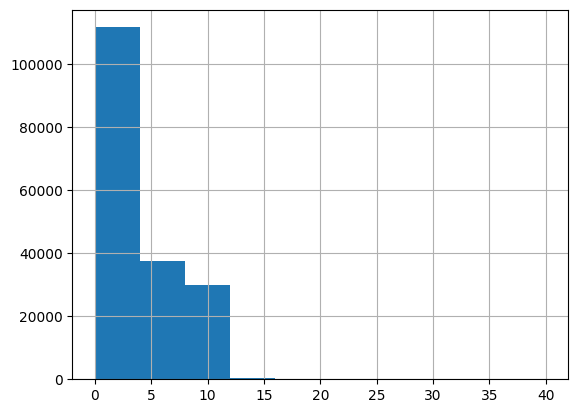

In [34]:
train_df["quantity_produced"].hist()

## CFS flag

Binary flag — very imbalanced, only ~5% of rows have `cfs_flag = 1`.

In [25]:
train_df["cfs_flag"].value_counts()

cfs_flag
0    171469
1      8384
Name: count, dtype: int64

## CFI flag

Unlike CFS, `is_cfi` is pretty evenly split (~51% / 49%), so it could be a more useful feature.

In [26]:
train_df["is_cfi"].value_counts()

is_cfi
1    91419
0    88434
Name: count, dtype: int64

## Line of business (`lob_desc`)

Ten lines of business, with one category dominating (~92% of rows). The labels are encoded/obfuscated in this dataset, so I'm looking at the distribution rather than the actual names.

In [27]:
train_df["lob_desc"].value_counts()

lob_desc
UTBJWJILJ                      166161
MDUJWHTSAJWLJI NSKWFX YWFSX      5424
IJQQ XYTWFLJ TJR                 4893
IFYF UWTYJHYNTS FUU YWFSX        1995
XYTWFLJ ZSXYWZHYZWJI             1093
IJQQ SJYBTWPNSL                   177
TJR SJYBTWPNSL                     56
XYTWFLJ NSYJLWFYJI TKKJW           21
IFYF RFSFLJRJSY                    21
YJQJHTR                            12
Name: count, dtype: int64

## Product family parent (`family_parent_desc`)

Checking the distribution across 216 parent families to see how concentrated it is and whether a lot of families are rare.

In [28]:
train_df["family_parent_desc"].value_counts()

family_parent_desc
HTQJYT                 17039
HMFRUNTS               16016
XMJQITS                10956
YJCTRF                 10158
LQFIJBFYJW              6990
                       ...  
RH-4510H KZLZNONFT         1
UJWQF HM                   1
FC650 RNZWF                1
UTBJWKQJCW770WFHPHT        1
RH-4000W XTUTY             1
Name: count, Length: 216, dtype: int64

## Product family (`family_desc`)

Same thing one level down (360 families). With this many levels, I'll probably want to group rare categories or rely on the parent family instead.

In [29]:
train_df["family_desc"].value_counts()

family_desc
HTQJYT UJ                 15011
HMFRUNTS UJ               13414
XMJQITS UJ                10088
YJCTRF UJ                  9858
LQFIJBFYJW UJ              6685
                          ...  
UTBJWKQJC W860 WFHP           1
ZYT TJRW                      1
LNGGTSXHWJJP IXX              1
UTBJWKQJC W670 WFHP HT        1
WJI GQZKK TJRWIXX             1
Name: count, Length: 360, dtype: int64

## Dates

Plotting `download_date` to see the time range covered and whether order volume is steady or has spikes/gaps.

<Axes: >

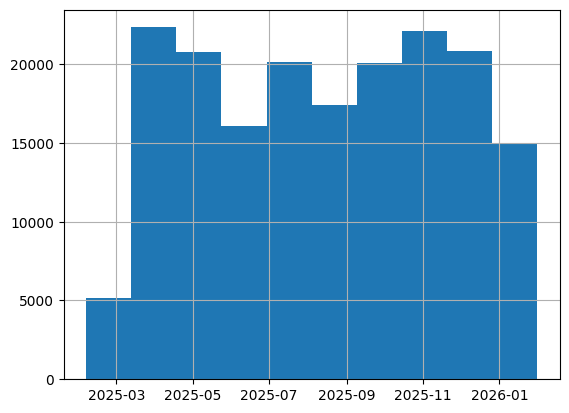

In [32]:
train_df["download_date"].hist()

Same for `kit_start`, to compare the timing of when builds actually start against when orders come in.

<Axes: >

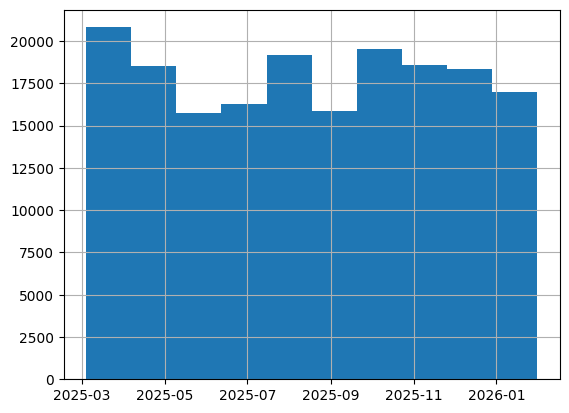

In [33]:
train_df["kit_start"].hist()